# 44 · NIAMS · bulk_RNA_seq · POST samples

Reads `counts_combatseq.rds`, `samples.rds` (notebook 40) and `top_genes_NIAMS_PRE_SAVI-CANDLE.csv` (notebook
43). Writes a heatmap to `figures/CANDLE_SAVI/`.

**Samples.** The NIAMS samples with Treatment = POST. All are CANDLE, so no comparison between diagnoses is
possible within POST.

**What is shown.** The top genes of the PRE comparison, SAVI against CANDLE (notebook 43), in the POST
samples: the ComBat-seq counts of notebook 40, log2 counts per million, z-scored per gene; Ward trees
(ward.D2, Minkowski p = 2) on both axes. This is a description; no test is applied.

## POST samples

In [1]:
source("../src/paths.R")
suppressMessages({library(edgeR); library(ComplexHeatmap); library(circlize)})
s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
post <- s[s$Sequencing_Facility == "NIAMS" & s$Treatment == "POST", ]
table(diagnosis = post$diagnosis, batch = post$batch)
c(samples = nrow(post), patients = length(unique(post$patient)))

         batch
diagnosis NIAMS-Batch1 NIAMS-Batch2
   CANDLE           29            4

samples patients 
      33        6

**Explanation**
- `post` keeps the NIAMS samples whose Treatment is POST; the table crosses diagnosis with the sequencing
  cohort, and the last line counts samples and patients.

**Result.** 33 POST samples, all CANDLE, from 6 patients: Batch1 29, Batch2 4.

## Heatmap of the PRE top genes

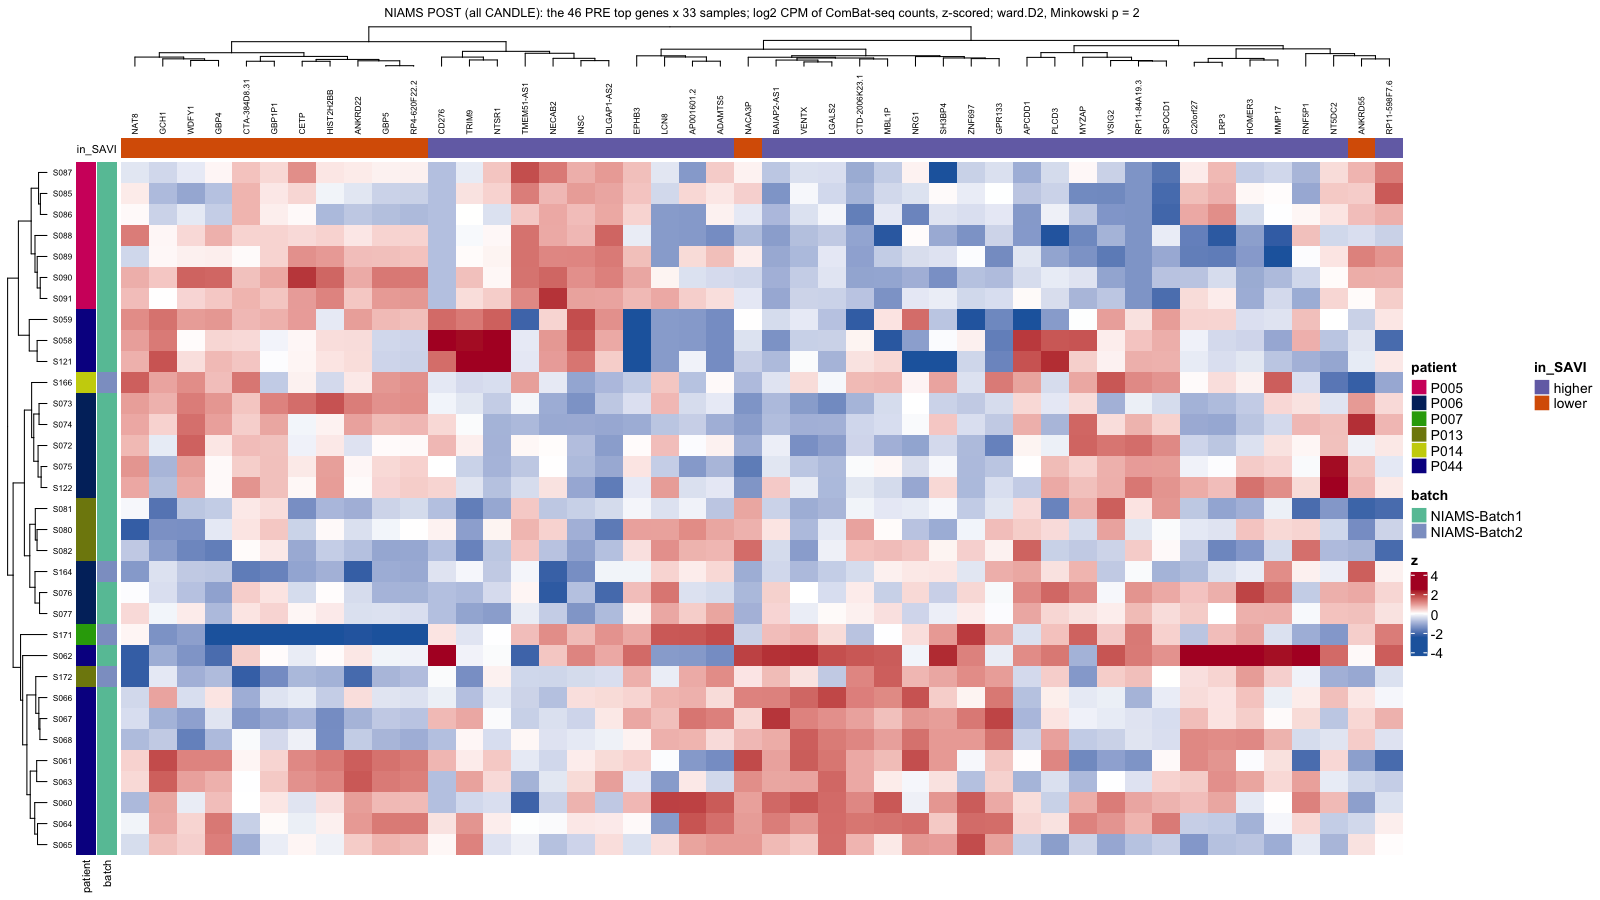

      patient
branch P005 P006 P007 P013 P014 P044
     1    7    0    0    0    0    3
     2    0    8    1    4    1    9

In [2]:
top <- read.csv(art("CANDLE_SAVI", "top_genes_NIAMS_PRE_SAVI-CANDLE.csv"))
xc  <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds"))
logcpm <- cpm(calcNormFactors(DGEList(xc$counts[, post$sample])), log = TRUE)
H  <- scale(t(logcpm[top$gene_id, , drop = FALSE])); H <- H[, colSums(is.na(H)) == 0, drop = FALSE]
Hc <- pmin(pmax(H, -2.5), 2.5)
hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
top_ann <- HeatmapAnnotation(in_SAVI = ifelse(top$logFC[match(colnames(H), top$gene_id)] > 0, "higher", "lower"),
                             col = list(in_SAVI = c(higher = "#7570B3", lower = "#D95F02")),
                             annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
left <- rowAnnotation(patient = post$patient, batch = post$batch, annotation_name_gp = gpar(fontsize = 8),
                      col = list(batch = c(`NIAMS-Batch1` = "#66C2A5", `NIAMS-Batch2` = "#8DA0CB")))
ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
              cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top", column_names_side = "top", row_names_side = "left",
              row_names_gp = gpar(fontsize = 6),
              column_labels = top$gene_name[match(colnames(H), top$gene_id)], column_names_gp = gpar(fontsize = 6),
              top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
              column_title = sprintf("NIAMS POST (all CANDLE): the %d PRE top genes x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", ncol(H), nrow(H)))
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "44_heatmap_NIAMS_POST.png") else tempfile(fileext = ".png")
  png(f, width = 16, height = 9, units = "in", res = res); draw(ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(hr, 2), patient = post$patient)

**Explanation**
- `top` holds the 46 top genes of the PRE comparison (notebook 43).
- The ComBat-seq counts of the POST samples, log2 counts per million, z-scored per gene; colours capped at
  -2.5 and 2.5.
- The strip on top marks whether each gene was higher or lower in SAVI than in CANDLE in the PRE comparison;
  the strips on the left show each sample's patient code and cohort.
- The heatmap is saved at 300 dpi and shown at 100 dpi, as in notebook 42.
- `cutree(hr, 2)` gives the first split of the sample tree; the table crosses it with patient.

**Result.** The first split of the sample tree follows patients: all 7 samples of P005 and 3 of the 12 samples
of P044 on one branch; all samples of P006 (8), P007 (1), P013 (4) and P014 (1) and the other 9 of P044 on the
other. No test is applied.

## The 28 interferon response genes and the 11 NF-kB-only controls

In [3]:
GENES <- xc$genes
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))

interferon_genes_found    control_genes_found 
                    28                     11

**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The last line counts the genes found.

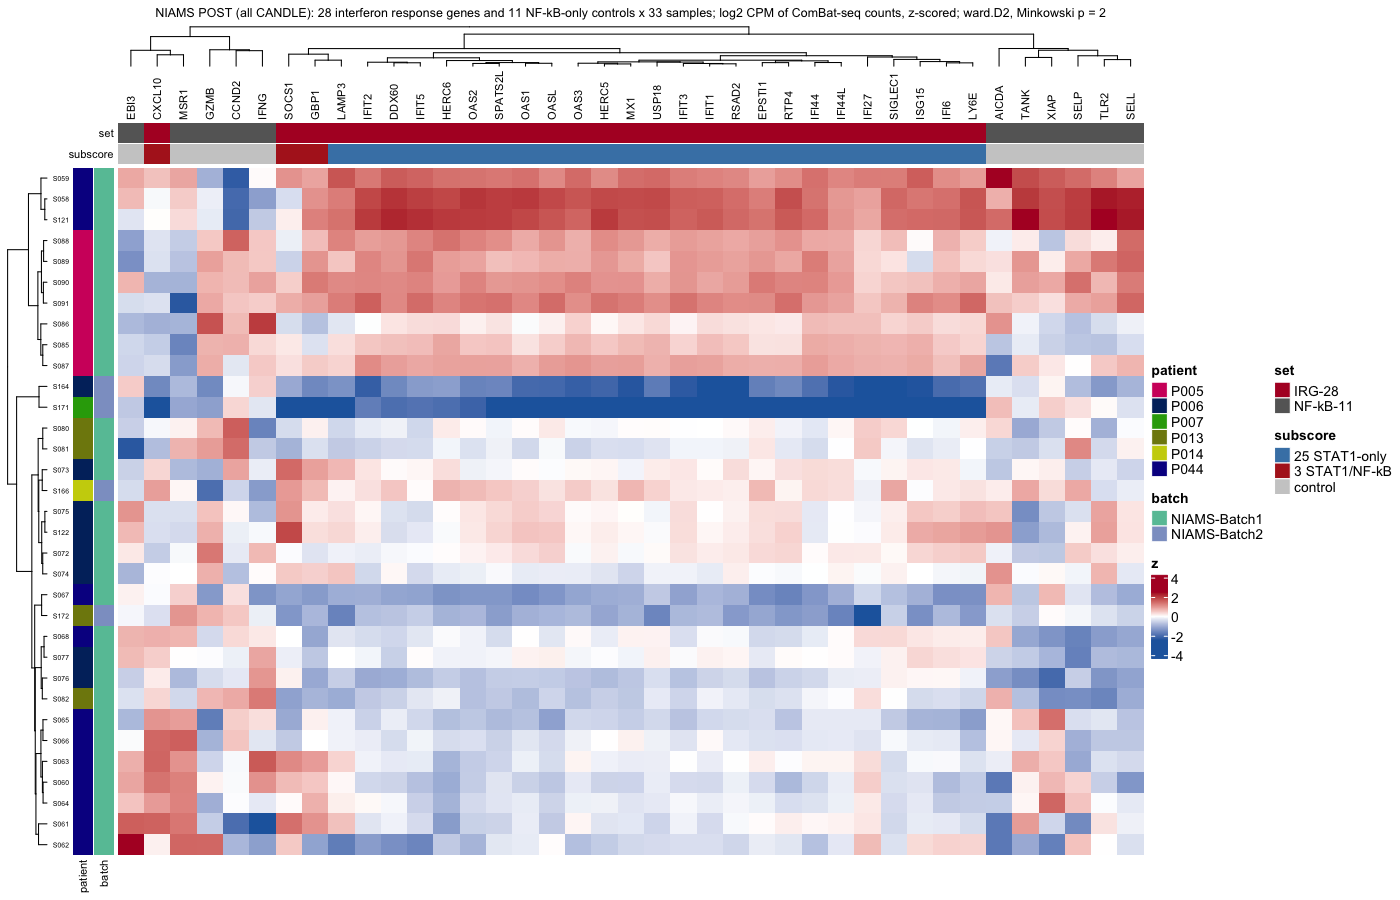

      patient
branch P005 P006 P007 P013 P014 P044
     1    7    0    0    0    0    3
     2    0    8    1    4    1    9

$`1`
[1] "CXCL10" "CCND2"  "EBI3"   "GZMB"   "IFNG"   "MSR1"  

$`2`
 [1] "DDX60"   "EPSTI1"  "GBP1"    "HERC5"   "HERC6"   "IFI27"   "IFI44"  
 [8] "IFI44L"  "IFI6"    "IFIT1"   "IFIT2"   "IFIT3"   "IFIT5"   "ISG15"  
[15] "LAMP3"   "LY6E"    "MX1"     "OAS1"    "OAS2"    "OAS3"    "OASL"   
[22] "RSAD2"   "RTP4"    "SIGLEC1" "SOCS1"   "SPATS2L" "USP18"   "AICDA"  
[29] "SELP"    "TANK"    "TLR2"    "SELL"    "XIAP"

In [4]:
r <- ifn_heat(logcpm, left, "NIAMS POST (all CANDLE)")
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "44_interferon_heatmap_NIAMS_POST.png") else tempfile(fileext = ".png")
  png(f, width = 14, height = 9, units = "in", res = res); draw(r$ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(r$rows, 2), patient = post$patient)
split(r$genes$gene_name, cutree(r$cols, 2))

**Explanation**
- `ifn_heat()` draws the heatmap; it is saved at 300 dpi and shown at 100 dpi.
- `cutree(r$rows, 2)` gives the first split of the sample tree, crossed with the samples' labels;
  `cutree(r$cols, 2)` gives the first split of the gene tree, listed by branch.

**Result.** The first split of the gene tree puts CXCL10 with 5 controls (CCND2, EBI3, GZMB, IFNG, MSR1), and
the other 27 interferon response genes with the other 6 controls. The first split of the sample tree separates
10 samples with higher interferon values (mean z of the 28 genes 0.92: all 7 of P005 and 3 of P044) from 23
with lower values (-0.40). No test is applied.

## References

The methods, gene lists and software used in this notebook.

1. R Core Team. *R: A Language and Environment for Statistical Computing*. R Foundation for Statistical Computing, Vienna, Austria.
2. Robinson MD, McCarthy DJ, Smyth GK. edgeR: a Bioconductor package for differential expression analysis of digital gene expression data. *Bioinformatics* 2010;26:139-140.
3. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
4. Gu Z, Eils R, Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics* 2016;32:2847-2849.
5. Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics* 2014;30:2811-2812.
6. Ward JH. Hierarchical grouping to optimize an objective function. *J Am Stat Assoc* 1963;58:236-244.
7. Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *J Classif* 2014;31:274-295.
8. Kim H, de Jesus AA, Brooks SR, Liu Y, Huang Y, VanTries R, et al. Development of a validated interferon score using NanoString technology. *J Interferon Cytokine Res* 2018;38:171-185.
9. de Jesus AA, Hou Y, Brooks S, Malle L, Biancotto A, Huang Y, et al. Distinct interferon signatures and cytokine patterns define additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669-1682.